# The Inverse Function and Its Derivative

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **inverse functions and their
derivatives** (Week 1 — Derivatives and Optimization).

This notebook explains:

- what an **inverse function** is — it *undoes* what $f$ does
- the notation $g = f^{-1}$ (not $1/f$) and the relation $g(f(x)) = x$
- the graph of $f^{-1}$ as a **reflection** of $f$ over the line $y = x$
- the key result $\;g'(y) = \dfrac{1}{f'(x)}\;$ — inverse slopes are **reciprocals**
- worked examples with $f(x) = x^2$ and $g(y) = \sqrt{y}$, verified with SymPy

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Some Common Derivatives — Other Power Functions*.

## 1. What is an inverse function?

> *"If your function does a certain thing, the inverse function undoes that thing."*

If $f$ sends $3 \to 5$, then $f^{-1}$ sends $5 \to 3$. (Mental image: $f$ puts a hat on a
person; the inverse takes the hat off, returning the original person.)

**Example.** If $f$ squares its input, the inverse takes the square root:

$$
f(x) = x^2, \qquad g(x) = \sqrt{x} \quad (x \ge 0,\ \text{positive root}),
$$

because squaring then square-rooting returns the original $x$.

## 2. Notation

If $g$ and $f$ are inverses, we write

$$
g(x) = f^{-1}(x).
$$

**Warning:** the $-1$ is *notation*, **not** a reciprocal — $f^{-1}(x) \ne \dfrac{1}{f(x)}$.
The defining property is

$$
g(f(x)) = x \qquad\text{(apply } f \text{, then } g \text{, and you get } x \text{ back).}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x', positive=True)
f = x**2
g = sp.sqrt(x)

# g undoes f:  g(f(x)) = x
print("g(f(x)) =", sp.simplify(g.subs(x, f)))   # x
print("f(g(x)) =", sp.simplify(f.subs(x, g)))   # x

g(f(x)) = x
f(g(x)) = x


## 3. The graph is a reflection over $y = x$

If the point $(a, b)$ is on the graph of $f$, then $(b, a)$ is on the graph of $f^{-1}$ —
the inverse's graph is the **reflection of $f$ across the diagonal $y = x$**.

For $f(x) = x^2$ and $g(y) = \sqrt{y}$:

| on $f = x^2$ | on $g = \sqrt{y}$ |
|---|---|
| $(\tfrac12, \tfrac14)$ | $(\tfrac14, \tfrac12)$ |
| $(1, 1)$ | $(1, 1)$ |
| $(\tfrac32, \tfrac94)$ | $(\tfrac94, \tfrac32)$ |

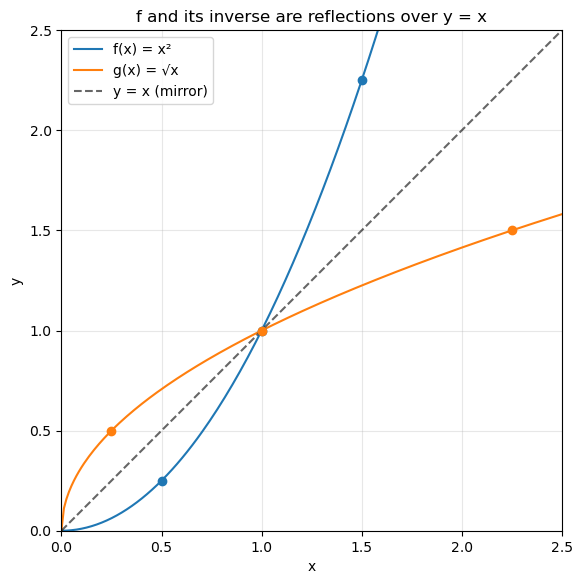

In [2]:
xs = np.linspace(0, 2.5, 200)
plt.figure(figsize=(6.5, 6.5))
plt.plot(xs, xs**2, label="f(x) = x²")
plt.plot(xs, np.sqrt(xs), label="g(x) = √x")
plt.plot(xs, xs, "k--", alpha=0.6, label="y = x (mirror)")
for a, b in [(0.5, 0.25), (1, 1), (1.5, 2.25)]:
    plt.plot(a, b, "o", color="tab:blue")
    plt.plot(b, a, "o", color="tab:orange")
plt.title("f and its inverse are reflections over y = x")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal"); plt.xlim(0, 2.5); plt.ylim(0, 2.5)
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. The derivative of the inverse

Take a secant on $f$ between $(1,1)$ and $(1.5, 2.25)$: its slope is $\dfrac{\Delta f}{\Delta x}$.
The corresponding secant on $g$ is the **reflection**, so the horizontal and vertical
distances swap:

$$
\Delta g = \Delta x, \qquad \Delta y = \Delta f .
$$

Therefore the inverse's secant slope is

$$
\frac{\Delta g}{\Delta y} = \frac{\Delta x}{\Delta f} .
$$

Taking $\Delta \to 0$: $f'(x) = \dfrac{\Delta f}{\Delta x}$ and $g'(y) = \dfrac{\Delta g}{\Delta y}$,
so

$$
\boxed{\;g'(y) = \frac{1}{f'(x)} \quad\text{where } y = f(x).\;}
$$

The slope of the inverse is the **reciprocal** of the slope of $f$.

## 5. Worked examples

For $f(x) = x^2$, $f'(x) = 2x$, and $g(y) = \sqrt{y}$:

- **At $(1,1)$:** $f'(1) = 2$, so $g'(1) = \dfrac{1}{2}$.
- **At $(2,4) \leftrightarrow (4,2)$:** $f'(2) = 4$, so $g'(4) = \dfrac{1}{4}$.

In general $g'(y) = \dfrac{1}{f'(x)} = \dfrac{1}{2x} = \dfrac{1}{2\sqrt{y}}$ — exactly the
power-rule derivative of $\sqrt{y}$.

In [3]:
x, y = sp.symbols('x y', positive=True)

fprime = sp.diff(x**2, x)            # 2x
gprime = sp.diff(sp.sqrt(y), y)      # 1/(2 sqrt(y))
print("f'(x) =", fprime)
print("g'(y) =", gprime)

for (xv, yv) in [(1, 1), (2, 4)]:
    print(f"  at x={xv} (y={yv}): f'={fprime.subs(x, xv)}, "
          f"g'={gprime.subs(y, yv)}  -> reciprocals? {sp.simplify(gprime.subs(y, yv) - 1/fprime.subs(x, xv))==0}")

# verify the identity g'(y) = 1/f'(x) with y = x^2
print("\ng'(y) with y=x²:", sp.simplify(gprime.subs(y, x**2)),
      " ==  1/f'(x):", sp.simplify(1/fprime))

f'(x) = 2*x
g'(y) = 1/(2*sqrt(y))
  at x=1 (y=1): f'=2, g'=1/2  -> reciprocals? True
  at x=2 (y=4): f'=4, g'=1/4  -> reciprocals? True

g'(y) with y=x²: 1/(2*x)  ==  1/f'(x): 1/(2*x)


### Reciprocal slopes, visually

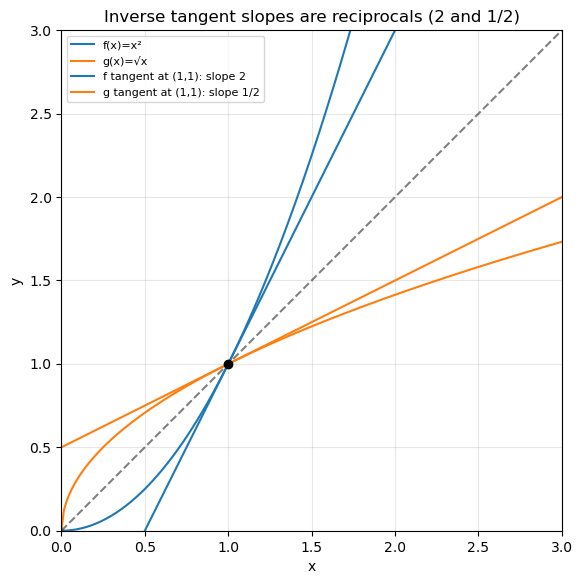

In [4]:
xs = np.linspace(0, 3, 200)
plt.figure(figsize=(6.5, 6.5))
plt.plot(xs, xs**2, label="f(x)=x²")
plt.plot(xs, np.sqrt(xs), label="g(x)=√x")
plt.plot(xs, xs, "k--", alpha=0.5)

# tangents at (1,1): slope 2 on f, slope 1/2 on g
plt.plot(xs, 1 + 2*(xs-1), color="tab:blue", lw=1.5, label="f tangent at (1,1): slope 2")
plt.plot(xs, 1 + 0.5*(xs-1), color="tab:orange", lw=1.5, label="g tangent at (1,1): slope 1/2")
plt.plot(1, 1, "ko")
plt.title("Inverse tangent slopes are reciprocals (2 and 1/2)")
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal"); plt.xlim(0, 3); plt.ylim(0, 3)
plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 6. Exercises

### Basic
1. In words, what does an inverse function do?
2. Does $f^{-1}(x)$ mean $1/f(x)$? Explain.

### Intermediate
3. For $f(x) = x^2$, what is $f'(3)$, and what is $g'(9)$ for $g = \sqrt{y}$?
4. Verify $g(f(x)) = x$ for $f(x) = x^2$, $g(x) = \sqrt{x}$ (for $x \ge 0$).

### Advanced
5. The inverse of $f(x) = e^x$ is $g(x) = \ln x$. Using $g'(y) = 1/f'(x)$ with $y = e^x$,
   show that $\dfrac{d}{dy}\ln y = \dfrac{1}{y}$.
6. Explain geometrically why the slope of $f^{-1}$ at $(b,a)$ is the reciprocal of the slope
   of $f$ at $(a,b)$.

## 7. Solutions / Checks

In [5]:
x, y = sp.symbols('x y', positive=True)

# 3.
fp = sp.diff(x**2, x)
gp = sp.diff(sp.sqrt(y), y)
print(f"3. f'(3) = {fp.subs(x,3)},  g'(9) = {gp.subs(y,9)}  (reciprocals)")

# 4.
print("4. g(f(x)) =", sp.simplify(sp.sqrt(x**2)))

# 5. ln as inverse of exp
fexp = sp.exp(x)
print("5. f'(x)=e^x, so g'(y)=1/e^x with y=e^x -> 1/y;  SymPy d/dy ln(y) =", sp.diff(sp.ln(y), y))

print("\n1. It undoes f: it maps outputs back to their original inputs.")
print("2. No - the -1 is notation for the inverse, not a reciprocal.")
print("6. The inverse's graph is the reflection over y=x, which swaps rise and run, so the "
      "slope inverts (reciprocal).")

3. f'(3) = 6,  g'(9) = 1/6  (reciprocals)
4. g(f(x)) = x
5. f'(x)=e^x, so g'(y)=1/e^x with y=e^x -> 1/y;  SymPy d/dy ln(y) = 1/y

1. It undoes f: it maps outputs back to their original inputs.
2. No - the -1 is notation for the inverse, not a reciprocal.
6. The inverse's graph is the reflection over y=x, which swaps rise and run, so the slope inverts (reciprocal).


## 8. Conclusion

- An **inverse function** $g = f^{-1}$ undoes $f$: $g(f(x)) = x$ (and $f^{-1} \ne 1/f$).
- Its graph is the **reflection** of $f$ over the line $y = x$, swapping each point
  $(a,b) \to (b,a)$.
- Because the reflection swaps rise and run, the inverse's slope is the **reciprocal**:

$$
g'(y) = \frac{1}{f'(x)}, \qquad y = f(x).
$$

- This recovers $\dfrac{d}{dy}\sqrt{y} = \dfrac{1}{2\sqrt{y}}$ and, for $e^x$/$\ln x$, gives
  $\dfrac{d}{dy}\ln y = \dfrac{1}{y}$ — a powerful shortcut for differentiating inverses.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (11).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **the inverse function and its derivative**. Key spoken points,
lightly cleaned:

> An inverse function undoes what $f$ does: if $f$ sends $3 \to 5$, the inverse sends $5 \to
> 3$ (like putting on and taking off a hat). If $f(x) = x^2$, the inverse is $g(x) =
> \sqrt{x}$ (for $x \ge 0$), since squaring then rooting returns $x$. Notation: $g(x) =
> f^{-1}(x)$, which is *not* $1/f(x)$; and $g(f(x)) = x$. The graph of the inverse is the
> reflection of $f$ over the line $y = x$, so a point $(a,b)$ on $f$ becomes $(b,a)$ on $g$.
> Drawing a secant and using the reflection, the horizontal and vertical distances swap:
> $\Delta g = \Delta x$ and $\Delta y = \Delta f$, so $\Delta g/\Delta y = \Delta x/\Delta
> f$. Taking limits, $g'(y) = 1/f'(x)$. For $f = x^2$ ($f' = 2x$): at $(1,1)$ the slope is
> $2$, so the inverse's slope is $1/2$; at $(2,4)$ the slope is $4$, so the inverse's slope
> at $(4,2)$ is $1/4$. So the derivative of the inverse is one over the derivative of $f$.